# video4 notebook - Road Potholes Detection
Notebook for detecting road potholes and depression defects.

In [35]:
import cv2
import os

# List available videos
if os.path.exists('videos'):
    video_files = [f for f in os.listdir('videos') if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    print("Available video files:")
    for f in video_files:
        print(f"  - {f}")
else:
    print("Warning: 'videos' folder not found")

video_path = 'videos/roadPothholes.mp4'
print(f"\nAttempting to load: {video_path}")

Available video files:
  - edgeCracking_06.mp4
  - pedestrianCrossingMarkRemoval_01.mp4
  - ravelling.mp4
  - roadPothholes.mp4

Attempting to load: videos/roadPothholes.mp4


In [36]:
import os
output_folder = "extracted_All_framesVideo4"
os.makedirs(output_folder, exist_ok=True)

In [37]:
cap = cv2.VideoCapture(video_path)

In [38]:
cap.isOpened()

True

In [39]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video file")
    print(f"File path: {video_path}")
    print("Please check if the file exists and is in the correct format")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if fps == 0:
        print("Error: Unable to read video FPS")
        print("The video file may be corrupted or in an unsupported format")
    else:
        duration_sec = total_frames / fps
        
        print('FPS:', fps)
        print('Total Frames:', total_frames)
        print('Video Duration(sec):', duration_sec)
        print("Video file opened successfully!")

FPS: 30.0
Total Frames: 695
Video Duration(sec): 23.166666666666668
Video file opened successfully!


In [40]:
frame_count = 0
saved_count = 0


while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % 5 == 0:
        resized = cv2.resize(frame, (640, 480))  
        filename = os.path.join(output_folder, f"frame_{saved_count}.jpg")
        cv2.imwrite(filename, resized)
        saved_count += 1

    frame_count += 1

cap.release()
print("Frame extraction completed!")
print("Total frames saved:", saved_count)

Frame extraction completed!
Total frames saved: 139


## Random 30-frame degradation analysis
This section:
- randomly selects 30 extracted frames,
- plots grayscale histograms,
- estimates noise, illumination issues, and blur,
- marks likely degradations per frame.

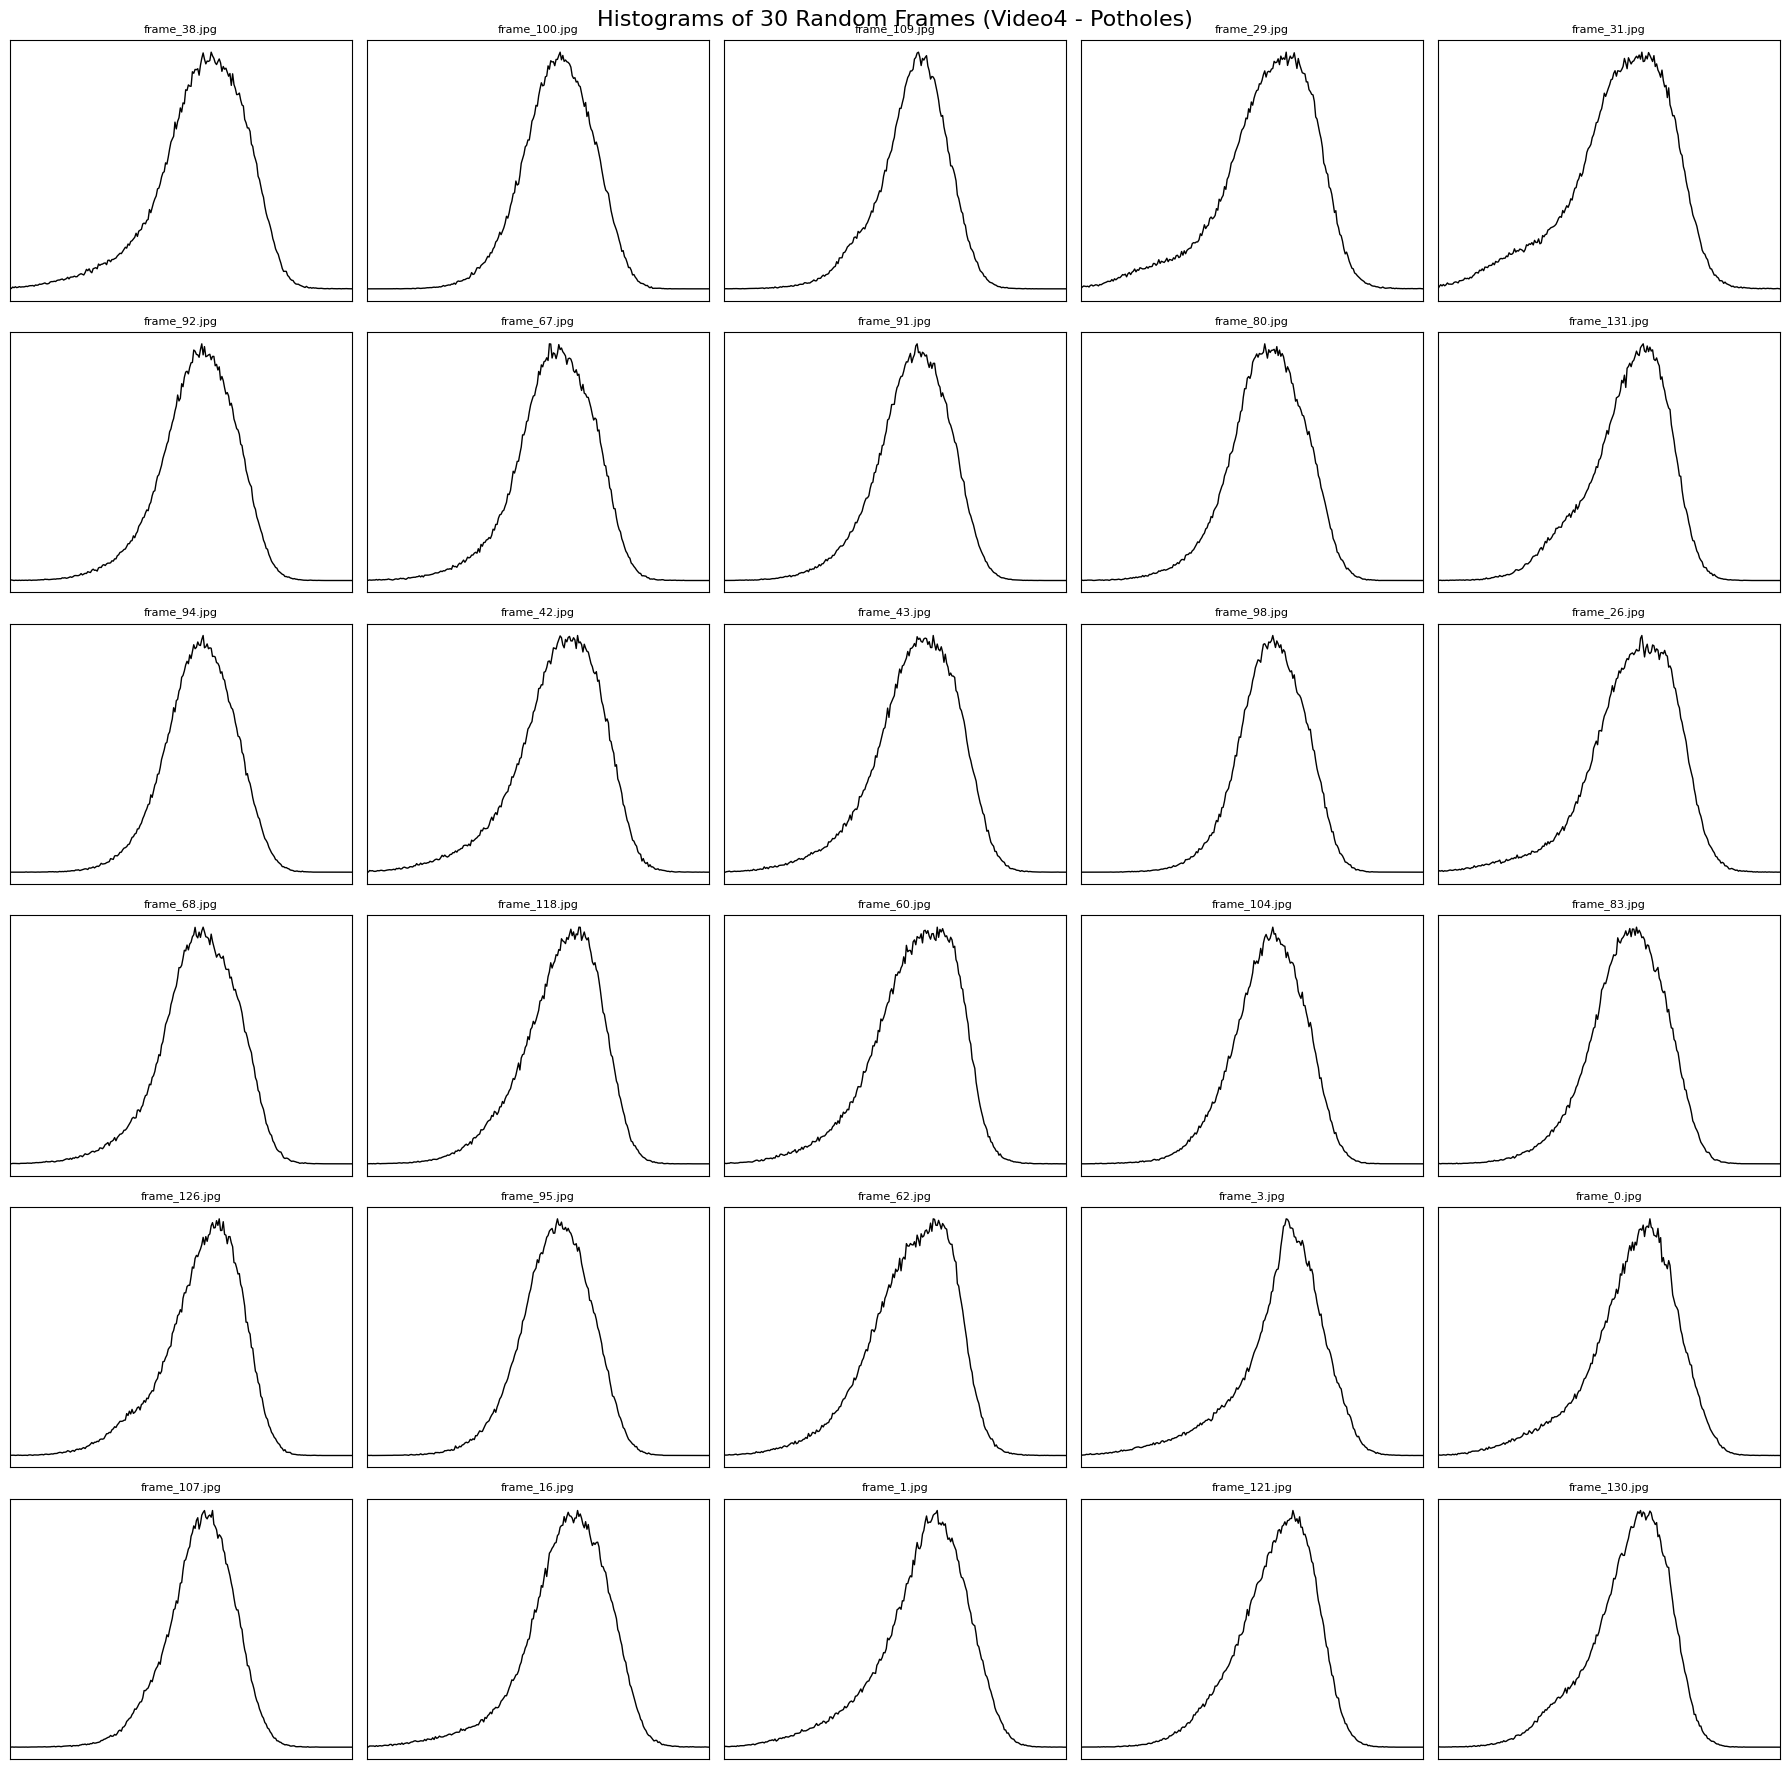

Analyzed frames: 30
Possible degradations summary:
  Noise-affected frames: 30
  Illumination-affected frames: 0
  Blur-affected frames: 0


,file,mean_brightness,sensor_noise_std,compression_blockiness,underexposed_pct,overexposed_pct,illumination_uneven_std,laplacian_var,noise_flag,illumination_flag,blur_flag
0,frame_38.jpg,142.20,21.24,0.0,0.96,0.16,17.32,8310.44,True,False,False
1,frame_100.jpg,142.22,16.45,0.0,0.04,0.03,11.33,4694.64,True,False,False
2,frame_109.jpg,140.48,14.80,0.0,0.13,0.03,14.96,3811.35,True,False,False
3,frame_29.jpg,138.54,22.17,0.0,1.64,0.18,16.63,9324.71,True,False,False
4,frame_31.jpg,135.22,22.85,0.0,2.10,0.19,18.14,9806.80,True,False,False
5,frame_92.jpg,140.05,18.88,0.0,0.19,0.03,10.06,6456.77,True,False,False
6,frame_67.jpg,139.69,18.64,0.0,0.38,0.04,12.79,6358.60,True,False,False
7,frame_91.jpg,140.49,18.23,0.0,0.18,0.03,10.63,5862.25,True,False,False
8,frame_80.jpg,138.55,17.45,0.0,0.21,0.02,12.61,5279.73,True,False,False
9,frame_131.jpg,141.38,18.14,0.0,0.17,0.04,16.85,5980.18,True,False,False


In [41]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

source_folder = "extracted_All_framesVideo4"
filtered_folder = "filteredVideo4"
os.makedirs(filtered_folder, exist_ok=True)

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
image_files = [f for f in os.listdir(source_folder) if f.lower().endswith(image_exts)]
image_files.sort()

if len(image_files) == 0:
    raise FileNotFoundError(f"No images found in '{source_folder}'")

sample_size = min(30, len(image_files))
selected_files = random.sample(image_files, sample_size)


def sensor_noise_std(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    residual = gray.astype(np.float32) - blur.astype(np.float32)
    return float(np.std(residual))


def compression_blockiness(gray):
    gray = gray.astype(np.float32)
    h, w = gray.shape

    vertical_boundaries = [x for x in range(8, w, 8)]
    horizontal_boundaries = [y for y in range(8, h, 8)]

    if len(vertical_boundaries) == 0 or len(horizontal_boundaries) == 0:
        return 0.0

    vb = np.mean([np.mean(np.abs(gray[:, x] - gray[:, x - 1])) for x in vertical_boundaries])
    hb = np.mean([np.mean(np.abs(gray[y, :] - gray[y - 1, :])) for y in horizontal_boundaries])

    vsi = [x for x in range(9, w - 1, 8)]
    hsi = [y for y in range(9, h - 1, 8)]

    vi = np.mean([np.mean(np.abs(gray[:, x] - gray[:, x - 1])) for x in vsi]) if len(vsi) else 0.0
    hi = np.mean([np.mean(np.abs(gray[y, :] - gray[y - 1, :])) for y in hsi]) if len(hsi) else 0.0

    return float(max(0.0, (vb + hb) - (vi + hi)))


def illumination_metrics(gray):
    under_pct = float(np.mean(gray < 40) * 100)
    over_pct = float(np.mean(gray > 215) * 100)

    illum_map = cv2.GaussianBlur(gray.astype(np.float32), (51, 51), 0)
    uneven_std = float(np.std(illum_map))

    return under_pct, over_pct, uneven_std


def blur_score(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


records = []

plt.figure(figsize=(18, 18))
for idx, fname in enumerate(selected_files, start=1):
    path = os.path.join(source_folder, fname)
    img = cv2.imread(path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    s_noise = sensor_noise_std(gray)
    c_noise = compression_blockiness(gray)
    under_pct, over_pct, uneven_std = illumination_metrics(gray)
    lap_var = blur_score(gray)
    mean_brightness = float(np.mean(gray))

    low_light_noise = (mean_brightness < 90) and (s_noise > 9.0)
    noise_flag = (s_noise > 10.0) or (c_noise > 2.5) or low_light_noise
    illumination_flag = (under_pct > 20.0) or (over_pct > 10.0) or (uneven_std > 30.0)
    blur_flag = lap_var < 80.0

    records.append(
        {
            "file": fname,
            "mean_brightness": round(mean_brightness, 2),
            "sensor_noise_std": round(s_noise, 2),
            "compression_blockiness": round(c_noise, 2),
            "underexposed_pct": round(under_pct, 2),
            "overexposed_pct": round(over_pct, 2),
            "illumination_uneven_std": round(uneven_std, 2),
            "laplacian_var": round(lap_var, 2),
            "noise_flag": bool(noise_flag),
            "illumination_flag": bool(illumination_flag),
            "blur_flag": bool(blur_flag),
        }
    )

    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    plt.subplot(6, 5, idx)
    plt.plot(hist, color="black", linewidth=1)
    plt.title(fname, fontsize=8)
    plt.xlim(0, 255)
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Histograms of 30 Random Frames (Video4 - Potholes)", fontsize=16)
plt.tight_layout()
plt.show()

analysis_df = pd.DataFrame(records)

print(f"Analyzed frames: {len(analysis_df)}")
print("Possible degradations summary:")
print(f"  Noise-affected frames: {int(analysis_df['noise_flag'].sum())}")
print(f"  Illumination-affected frames: {int(analysis_df['illumination_flag'].sum())}")
print(f"  Blur-affected frames: {int(analysis_df['blur_flag'].sum())}")

analysis_df.head(10)

Filtered images saved: 30
Output folder: filteredVideo4


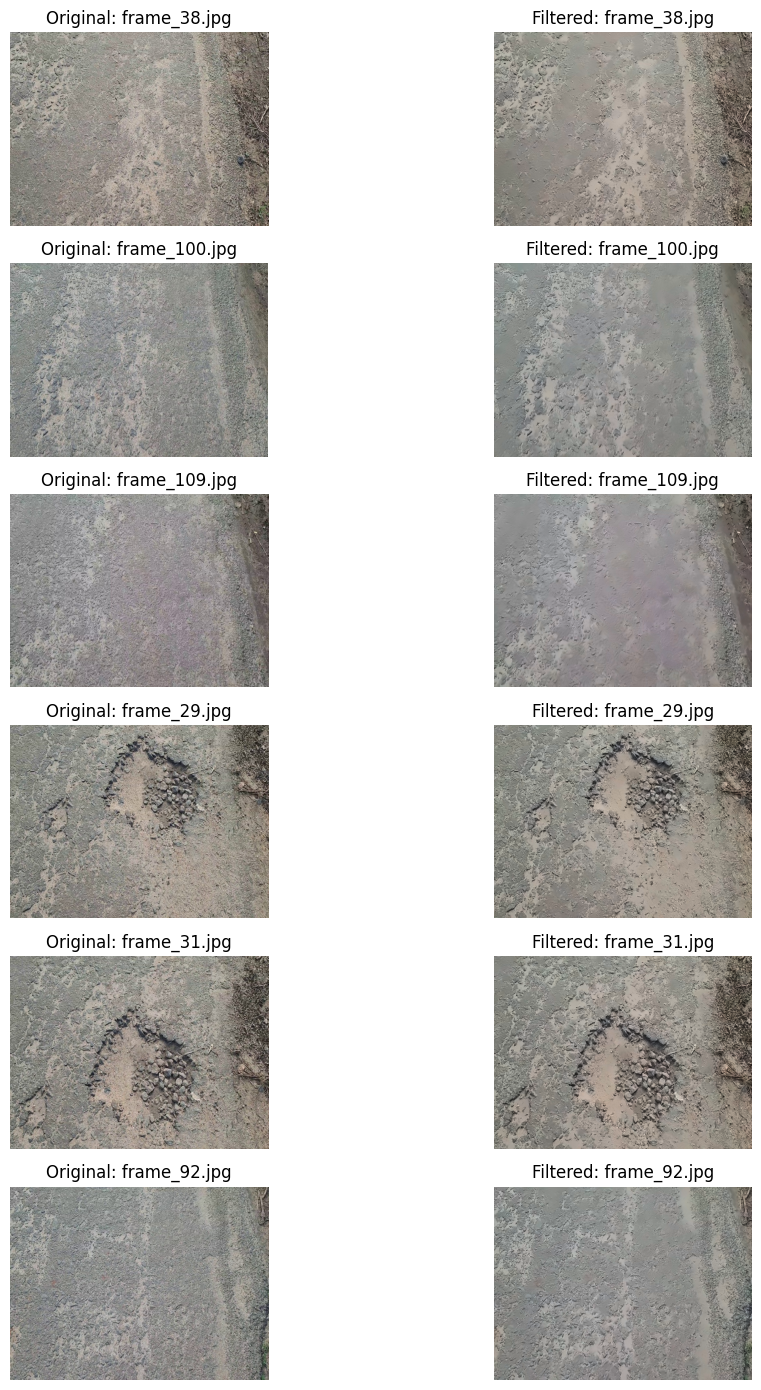

In [42]:
def apply_adaptive_filter(img_bgr, row):
    out = img_bgr.copy()

    if row["noise_flag"]:
        out = cv2.fastNlMeansDenoisingColored(out, None, 7, 7, 7, 21)

    if row["illumination_flag"]:
        lab = cv2.cvtColor(out, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.2, tileGridSize=(8, 8))
        l2 = clahe.apply(l)
        out = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)

    if row["blur_flag"]:
        blur = cv2.GaussianBlur(out, (0, 0), 1.1)
        out = cv2.addWeighted(out, 1.55, blur, -0.55, 0)

    return out


saved = 0
preview_pairs = []

for _, row in analysis_df.iterrows():
    src_path = os.path.join(source_folder, row["file"])
    dst_path = os.path.join(filtered_folder, row["file"])

    img = cv2.imread(src_path)
    if img is None:
        continue

    filtered = apply_adaptive_filter(img, row)
    cv2.imwrite(dst_path, filtered)

    if len(preview_pairs) < 6:
        preview_pairs.append((img, filtered, row["file"]))

    saved += 1

print(f"Filtered images saved: {saved}")
print(f"Output folder: {filtered_folder}")

if len(preview_pairs) > 0:
    plt.figure(figsize=(12, 14))
    for i, (orig, filt, fname) in enumerate(preview_pairs, start=1):
        plt.subplot(len(preview_pairs), 2, 2 * i - 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {fname}")
        plt.axis("off")

        plt.subplot(len(preview_pairs), 2, 2 * i)
        plt.imshow(cv2.cvtColor(filt, cv2.COLOR_BGR2RGB))
        plt.title(f"Filtered: {fname}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Diagnostic: Visualize detection masks
This section shows what the pothole detection algorithm sees - helpful for understanding why potholes may not be detected

Processed frames: 139
Total dark regions marked: 1154
Frames with detections: 139
Output: detectedPotholeVideo4/


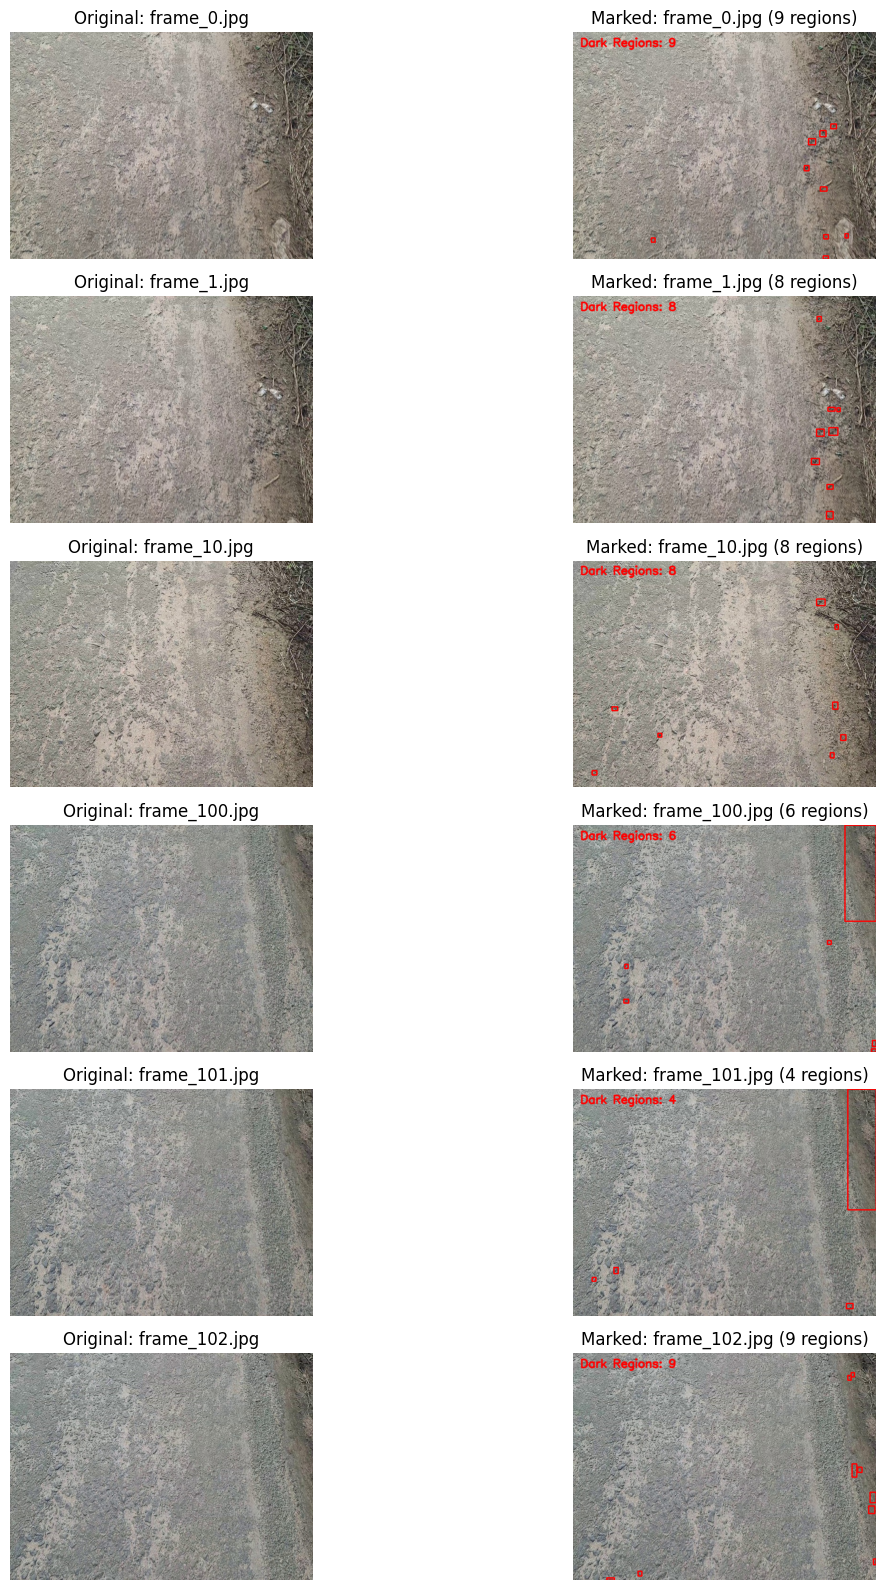

In [45]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

extracted_folder = "extracted_All_framesVideo4"  
marked_folder = "detectedPotholeVideo4"
os.makedirs(marked_folder, exist_ok=True)


def detect_pothole_parts(img_bgr):
    """
    Find the darkest connected regions - these are most likely potholes.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    # Use histogram to find the darkest regions adaptively
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    
    # Find the 30th percentile of pixel values (darkest 30%)
    cumsum = np.cumsum(hist)
    cumsum = cumsum / cumsum[-1]  # Normalize
    dark_threshold_idx = np.argmax(cumsum >= 0.30)  # Value that covers darkest 30%
    dark_threshold = max(50, min(100, dark_threshold_idx))  # Clamp reasonable range
    
    # Binary mask of dark regions
    _, binary = cv2.threshold(gray, dark_threshold, 255, cv2.THRESH_BINARY_INV)
    
    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    img_area = h * w
    detections = []
    
    # Score each contour by area and darkness
    for cnt in contours:
        area = cv2.contourArea(cnt)
        
        # Size filter
        if area < 30 or area > 0.4 * img_area:
            continue
        
        x, y, bw, bh = cv2.boundingRect(cnt)
        if bh == 0 or bw == 0:
            continue
        
        # Get mean darkness of the region
        region = gray[y:y+bh, x:x+bw]
        mean_darkness = 255 - np.mean(region)  # Invert so higher = darker
        
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        solidity = area / float(hull_area)
        
        # Very relaxed constraints
        if solidity < 0.10:  # Very low threshold
            continue
        
        detections.append({
            "bbox": (x, y, bw, bh),
            "area": area,
            "darkness": mean_darkness,
            "solidity": solidity
        })
    
    # Sort by darkness and keep top detections
    detections = sorted(detections, key=lambda d: d["darkness"], reverse=True)[:10]
    
    # Remove duplicates (overlapping boxes)
    filtered = []
    for d in detections:
        x1, y1, w1, h1 = d["bbox"]
        is_duplicate = False
        for f in filtered:
            x2, y2, w2, h2 = f["bbox"]
            dx = abs((x1 + w1/2) - (x2 + w2/2))
            dy = abs((y1 + h1/2) - (y2 + h2/2))
            if dx < max(w1, w2) and dy < max(h1, h2):
                is_duplicate = True
                break
        if not is_duplicate:
            filtered.append(d)
    
    return filtered


# Process ALL extracted frames
input_folder = extracted_folder
files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))])

summary = []
preview = []
total_detections = 0

for fname in files:
    src_path = os.path.join(input_folder, fname)
    dst_path = os.path.join(marked_folder, fname)

    img = cv2.imread(src_path)
    if img is None:
        continue

    detections = detect_pothole_parts(img)
    marked = img.copy()

    pothole_color = (0, 0, 255)  # Red

    for d in detections:
        x, y, bw, bh = d["bbox"]
        cv2.rectangle(marked, (x, y), (x + bw, y + bh), pothole_color, 2)
        total_detections += 1

    label = f"Dark Regions: {len(detections)}"
    cv2.putText(marked, label, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, pothole_color, 2, cv2.LINE_AA)

    cv2.imwrite(dst_path, marked)

    summary.append({"file": fname, "detected_potholes": len(detections)})

    if len(preview) < 6:
        preview.append((img, marked, fname, len(detections)))

print(f"Processed frames: {len(summary)}")
print(f"Total dark regions marked: {total_detections}")
print(f"Frames with detections: {sum(1 for s in summary if s['detected_potholes'] > 0)}")
print(f"Output: {marked_folder}/")

if len(preview) > 0:
    plt.figure(figsize=(14, 16))
    for i, (orig, marked, fname, n) in enumerate(preview, start=1):
        plt.subplot(len(preview), 2, 2 * i - 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {fname}")
        plt.axis("off")

        plt.subplot(len(preview), 2, 2 * i)
        plt.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
        plt.title(f"Marked: {fname} ({n} regions)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

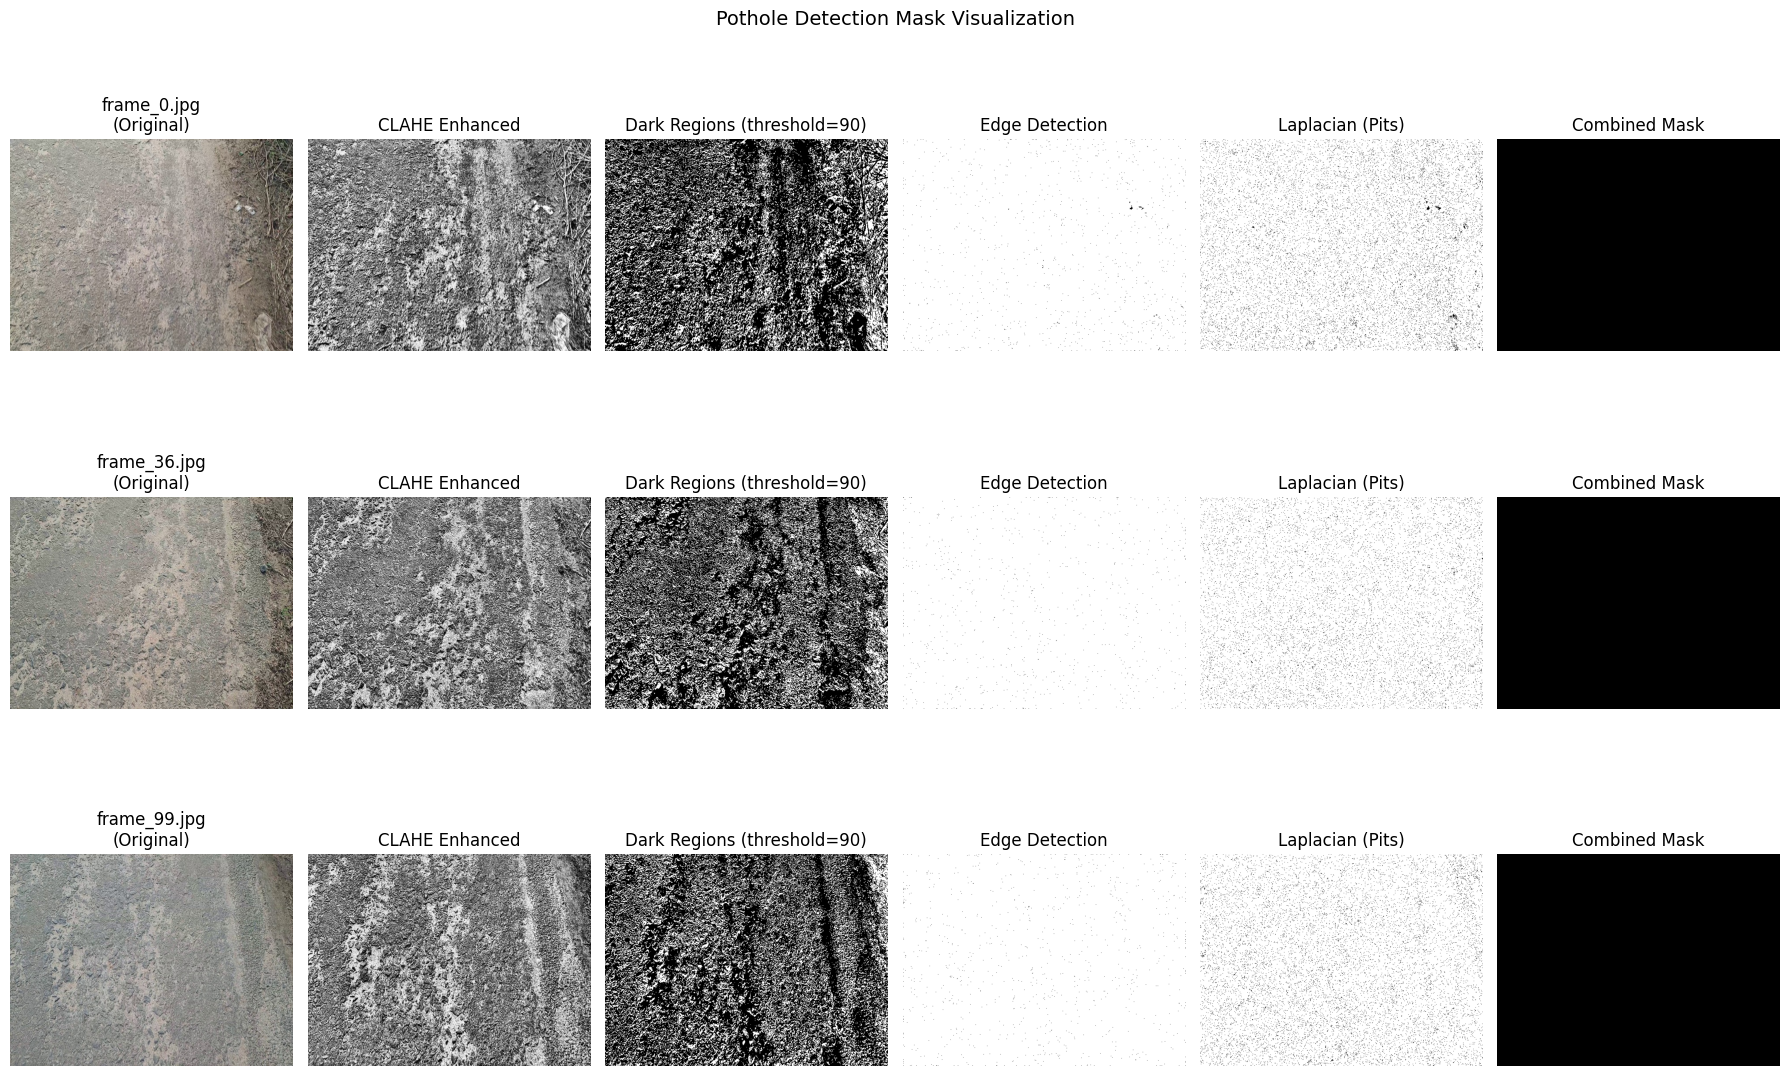

Sample frames analyzed: 3
Check the masks above - if they're mostly black, adjust thresholds


In [44]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Select a few sample frames to visualize detection masks
extracted_folder = "extracted_All_framesVideo4"
image_files = sorted([f for f in os.listdir(extracted_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))])

# Sample frames from beginning, middle, and end
sample_indices = [0, len(image_files)//2, len(image_files)-1]
sample_files = [image_files[i] for i in sample_indices if i < len(image_files)]

fig, axes = plt.subplots(len(sample_files), 6, figsize=(18, 4*len(sample_files)))

for row, fname in enumerate(sample_files):
    src_path = os.path.join(extracted_folder, fname)
    img = cv2.imread(src_path)
    if img is None:
        continue
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(6, 6))
    gray_eq = clahe.apply(gray)
    
    # Individual detection masks
    _, dark = cv2.threshold(gray_eq, 90, 255, cv2.THRESH_BINARY_INV)
    
    sobelx = cv2.Sobel(gray_eq, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray_eq, cv2.CV_64F, 0, 1, ksize=3)
    edge_mag = np.sqrt(sobelx**2 + sobely**2)
    edge_mag = np.uint8(np.clip(edge_mag, 0, 255))
    _, edge = cv2.threshold(edge_mag, 15, 255, cv2.THRESH_BINARY)
    
    laplacian = cv2.Laplacian(gray_eq, cv2.CV_64F)
    laplacian_abs = np.uint8(np.clip(np.abs(laplacian), 0, 255))
    _, laplacian_mask = cv2.threshold(laplacian_abs, 10, 255, cv2.THRESH_BINARY)
    
    # Combined
    combined = cv2.bitwise_or(cv2.bitwise_or(dark, edge), laplacian_mask)
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel_clean, iterations=1)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel_clean, iterations=1)
    
    # Plot
    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'{fname}\n(Original)')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(gray_eq, cmap='gray')
    axes[row, 1].set_title('CLAHE Enhanced')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(dark, cmap='gray')
    axes[row, 2].set_title('Dark Regions (threshold=90)')
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(edge, cmap='gray')
    axes[row, 3].set_title('Edge Detection')
    axes[row, 3].axis('off')
    
    axes[row, 4].imshow(laplacian_mask, cmap='gray')
    axes[row, 4].set_title('Laplacian (Pits)')
    axes[row, 4].axis('off')
    
    axes[row, 5].imshow(combined, cmap='gray')
    axes[row, 5].set_title('Combined Mask')
    axes[row, 5].axis('off')

plt.suptitle('Pothole Detection Mask Visualization', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Sample frames analyzed: {len(sample_files)}")
print("Check the masks above - if they're mostly black, adjust thresholds")
